# Ocean Heat Transport By Basin

Create a CMIP7 monthly northward ocean heat transport file (`htovgyre_tavg-u-hyb-sea`) using latitude and ocean basin coordinates read from a source dataset with xarray.

In [ ]:
from pathlib import Path
import calendar
import json
import shutil

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "htovgyre_Omon_UKESM1-0-LL_ssp370-lowNTCFCH4_r2i1p1f2_gnz_201501-204912.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")



def month_year_label(time_coord):
    decoded_time = xr.coding.times.decode_cf_datetime(
        time_coord.values[:1],
        time_coord.attrs["units"],
        calendar=time_coord.attrs.get("calendar", "standard"),
    )[0]
    if hasattr(decoded_time, "strftime"):
        return decoded_time.strftime("%B %Y")
    date_text = np.datetime_as_string(decoded_time, unit="D")
    year, month = date_text.split("-")[:2]
    return f"{calendar.month_name[int(month)]} {year}"


print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [ ]:
with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(source)


<xarray.Dataset> Size: 2MB
Dimensions:    (time: 420, bnds: 2, lat: 330, basin: 3)
Coordinates:
  * time       (time) float64 3kB 5.942e+04 5.944e+04 ... 7.196e+04 7.198e+04
  * lat        (lat) float64 3kB -85.35 -85.19 -85.04 ... 81.73 81.77 81.79
    sector     (basin) |S21 63B b'atlantic_arctic_ocean' ... b'indian_pacific...
Dimensions without coordinates: bnds, basin
Data variables:
    time_bnds  (time, bnds) float64 7kB 5.94e+04 5.943e+04 ... 7.197e+04 7.2e+04
    lat_bnds   (lat, bnds) float64 5kB -85.42 -85.27 -85.27 ... 81.78 81.78 81.8
    htovgyre   (time, basin, lat) float32 2MB nan nan nan nan ... nan nan nan
Attributes:
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            AerChemMIP
    branch_method:          standard
    branch_time_in_child:   59400.0
    branch_time_in_parent:  59400.0
    creation_date:          2020-08-21T14:28:52Z
    cv_version:             6.2.53.5
    data_specs_version:     01.00.31
    experiment:             SSP3-7.0, with low NTCF emissions and methane con...
    experiment_id:          ssp370-lowNTCFCH4
    forcing_index:          2
    frequency:              mon
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.MOHC.UKESM1-...
    grid:                   Native eORCA1 tripolar primarily 1 deg with merid...
    grid_label:             gnz
    history:                2020-08-21T14:24:56Z ; CMOR rewrote data to be co...
    initialization_index:   1
    institution:            Met Office Hadley Centre, Fitzroy Road, Exeter, D...
    institution_id:         MOHC
    mip_era:                CMIP6
    mo_runid:               u-bu258
    nominal_resolution:     100 km
    parent_activity_id:     CMIP
    parent_experiment_id:   historical
    parent_mip_era:         CMIP6
    parent_source_id:       UKESM1-0-LL
    parent_time_units:      days since 1850-01-01
    parent_variant_label:   r4i1p1f2
    physics_index:          1
    product:                model-output
    realization_index:      2
    realm:                  ocean
    source:                 UKESM1.0-LL (2018): \naerosol: UKCA-GLOMAP-mode\n...
    source_id:              UKESM1-0-LL
    source_type:            AOGCM AER BGC CHEM
    sub_experiment:         none
    sub_experiment_id:      none
    table_id:               Omon
    table_info:             Creation Date:(22 July 2019) MD5:4dd1814731b1436d...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/a774509f-e0a8-463b-a6ea-d77330aa8c17
    variable_id:            htovgyre
    variable_name:          htovgyre
    variant_label:          r2i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0

In [ ]:
run_dir = Path("output") / "05_ocean_heat_transport_by_basin"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": source["time"].attrs.get("calendar", "standard"),
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

time = source["time"].values.astype("f8")
time_bnds = source["time_bnds"].values.astype("f8")
time_units = source["time"].attrs["units"]
lat = source["lat"].values.astype("f8")
lat_bnds = source["lat_bnds"].values.astype("f8")
basin = [value.decode() if isinstance(value, bytes) else str(value) for value in source["sector"].values]

missing_value = np.float32(1.0e20)
htovgyre_source = source["htovgyre"].values.astype("f4")
htovgyre = np.where(np.isfinite(htovgyre_source), htovgyre_source, missing_value).astype("f4")

print(htovgyre.shape)


(420, 3, 330)


In [ ]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))

ocean_table = cmor.load_table("CMIP7_ocean.json")

cmor.set_table(ocean_table)
time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)
basin_id = cmor.axis("basin", coord_vals=basin, units="1")
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")

variable_name = "htovgyre_tavg-u-hyb-sea"
htovgyre_id = cmor.variable(variable_name, "W", [time_id, basin_id, lat_id], missing_value=missing_value)
compound_name = ".".join(["ocean"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(htovgyre_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(htovgyre_id, "long_name", "c", long_name)

cmor.write(htovgyre_id, htovgyre)
netcdf_path = Path(cmor.close(htovgyre_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))


output/05_ocean_heat_transport_by_basin/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/htovgyre/tavg-u-hyb-sea/g999/v20260531/htovgyre_tavg-u-hyb-sea_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_201501-204912.nc


In [ ]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(ds)

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 420, bnds: 2, lat: 330, basin: 3)
Coordinates:
  * time       (time) float64 3kB 5.942e+04 5.944e+04 ... 7.196e+04 7.198e+04
  * lat        (lat) float64 3kB -85.35 -85.19 -85.04 ... 81.73 81.77 81.79
    sector     (basin) |S21 63B b'atlantic_arctic_ocean' ... b'indian_pacific...
Dimensions without coordinates: bnds, basin
Data variables:
    time_bnds  (time, bnds) float64 7kB 5.94e+04 5.943e+04 ... 7.197e+04 7.2e+04
    lat_bnds   (lat, bnds) float64 5kB -85.42 -85.27 -85.27 ... 81.78 81.78 81.8
    htovgyre   (time, basin, lat) float32 2MB nan nan nan nan ... nan nan nan
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            sea
    branded_variable:      htovgyre_tavg-u-hyb-sea
    branding_suffix:       tavg-u-hyb-sea
    creation_date:         2026-05-31T18:59:25Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-31T18:59:25Z ; CMOR rewrote data to be con...
    horizontal_label:      hyb
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    100 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 ocean
    region:                glb
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_ocean.json; Creation Date:(2026-04-21 ...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/41f234e7-b654-4df4-b6c3-b786c3dcb125
    variable_id:           htovgyre
    variant_label:         r9i1p1f3
    vertical_label:        u
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

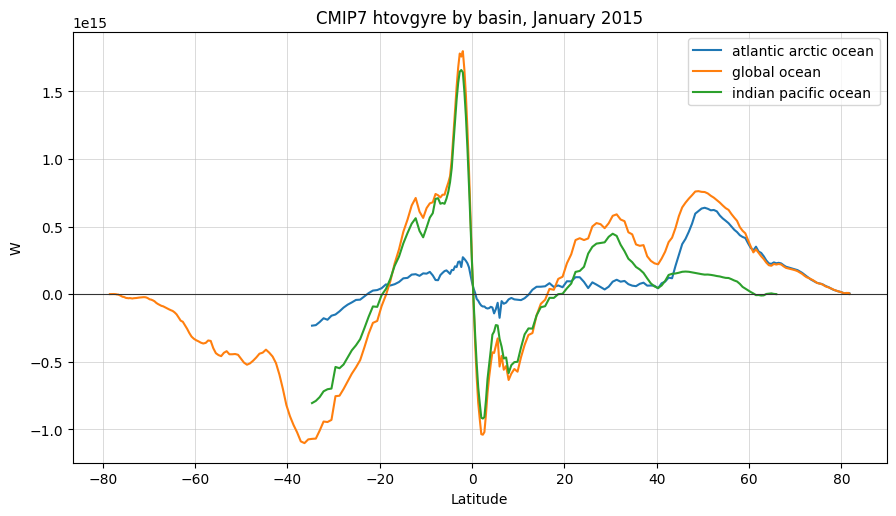

In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 5.6))
basin_values = [value.decode() if isinstance(value, bytes) else str(value) for value in ds["sector"].values]
field = ds["htovgyre"].isel(time=0)
for basin_index, basin_name in enumerate(basin_values):
    ax.plot(ds["lat"].values, field.isel(basin=basin_index).values, label=basin_name.replace("_", " "))
ax.axhline(0.0, color="0.2", linewidth=0.8)
ax.set_xlabel("Latitude")
ax.set_ylabel("W")
time_label = month_year_label(ds["time"])
ax.set_title(f"CMIP7 htovgyre by basin, {time_label}")
ax.grid(True, linewidth=0.4, color="0.75")
ax.legend(loc="best")
plt.show()
